# **Climate Forecasting using Machine Learning: 04 Temporal Feature Tuning**

---

### **Notebook Summary**

This notebook tunes temporal feature design after the training and selection strategy has been fixed. The first section sweeps autoregressive lag structures. The second section fixes the selected AR memory design and tunes the ENSO lag representation.

### **Temporal feature settings**
- H = 1
- AR + ENSO features
- SST off
- QMAP off
- 48-month recency weighting fixed
- global model selection fixed
- AR lag structure varied first
- ENSO lag set varied second

### **What this notebook should answer**
1. Which AR lag structure gives the best held-out performance?
2. Does dense annual memory outperform sparse seasonal memory?
3. Which ENSO lag set should be carried forward?
4. Do lag choices change the selected model mix across month groups?

---

# **Part 1: Configuration**

### **Imports**

In [1]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def find_project_root(start: Path) -> Path:
    return next(
        candidate
        for candidate in [start, *start.parents]
        if (candidate / "src" / "forecaster" / "__init__.py").exists()
    )


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC_DIR = PROJECT_ROOT / "src"
sys.path.insert(0, str(SRC_DIR))


def project_relative(path):
    return Path(path).resolve().relative_to(PROJECT_ROOT).as_posix()


def portable_config(config):
    portable = dict(vars(config)) if hasattr(config, "__dict__") else dict(config)

    for key in ("tavg_file", "sst_dir", "enso_csv"):
        if key in portable and portable[key] is not None:
            portable[key] = project_relative(portable[key])

    return portable


from forecaster.config import ForecasterConfig
from forecaster.pipeline import run_backtest
from forecaster.experiments import summarize_run as _summarize_run


pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 220)

print("Repository setup complete.")
print("Import path: src")

Repository setup complete.
Import path: src


### **Figure export helper**


In [2]:
IMAGE_DIR = PROJECT_ROOT / "experiment_notebooks/Experiment_Images_For_Case_Analysis"
IMAGE_DIR.mkdir(parents=True, exist_ok=True)


def save_current_plot(filename: str, *, dpi: int = 180):
    path = IMAGE_DIR / filename
    plt.savefig(path, dpi=dpi, bbox_inches="tight", facecolor="white")
    print("Saved figure:", path.relative_to(PROJECT_ROOT))
    return path


print("Case-analysis image folder:", IMAGE_DIR.relative_to(PROJECT_ROOT))

Case-analysis image folder: experiment_notebooks/Experiment_Images_For_Case_Analysis


### **Data paths**

In [3]:
DATA_DIR = PROJECT_ROOT / "noaa_raw_data"
TAVG_FILE = str(DATA_DIR / "nclimgrid_tavg.nc")
SST_DIR = str(DATA_DIR / "sst_cache")
ENSO_CSV = str(DATA_DIR / "nina34.anom.csv")
RANDOM_SEED = 42

print("TAVG exists:", Path(TAVG_FILE).exists())
print("SST dir exists:", Path(SST_DIR).exists())
print("ENSO CSV exists:", Path(ENSO_CSV).exists())

TAVG exists: True
SST dir exists: True
ENSO CSV exists: True


### **Base configuration**

This cell fixes the selected feature scope, 48-month recency weighting, and global model-selection setup before changing AR lags. That keeps the lag sweep focused on temporal memory rather than model setup changes.

In [4]:
RESEARCH_MODEL_SET = [
    "Ridge",
    "Huber",
    "XGBoost",
    "LSTM",
    "PatchTST",
    "iTransformer",
    "NHiTS",
]


BASE_CFG = dict(
    tavg_file=TAVG_FILE,
    sst_dir=SST_DIR,
    enso_csv=ENSO_CSV,
    random_seed=RANDOM_SEED,

    use_sst=False,
    use_teleconnections=False,

    use_qmap=False,
    use_month_alpha_choice=False,
    month_group_size=12,

    # Compact research model set
    use_ridge=True,
    use_huber=True,
    use_xgb=True,
    use_lstm=True,
    use_patchtst=True,
    use_itransformer=True,
    use_nhits=True,


    H=1,

    use_recency_weights=True,
    half_life_months=48,

    residual_deseasonalize=False,

    plot_test=False,
    verbose=True,
)

print("Research model set:", RESEARCH_MODEL_SET)
portable_config(BASE_CFG)

Research model set: ['Ridge', 'Huber', 'XGBoost', 'LSTM', 'PatchTST', 'iTransformer', 'NHiTS']


{'tavg_file': 'nclimgrid_tavg.nc',
 'sst_dir': 'sst_cache',
 'enso_csv': 'nina34.anom.csv',
 'random_seed': 42,
 'use_sst': False,
 'use_teleconnections': False,
 'use_qmap': False,
 'use_month_alpha_choice': False,
 'month_group_size': 12,
 'use_ridge': True,
 'use_huber': True,
 'use_xgb': True,
 'use_lstm': True,
 'use_patchtst': True,
 'use_itransformer': True,
 'use_nhits': True,
 'H': 1,
 'use_recency_weights': True,
 'half_life_months': 48,
 'residual_deseasonalize': False,
 'plot_test': False,
 'verbose': True}

### **Refined lag structures**

Each option represents a different assumption about how much past anomaly information should be available to the model. The sweep compares sparse memory, dense recent annual memory, and longer lag windows.

In [5]:
LAG_STRUCTURES = {
    "AR_18": list(range(1, 19)),
    "AR_24": list(range(1, 25)),
    "AR_12_plus_24": list(range(1, 13)) + [24],
    "AR_seasonal_sparse": [1, 2, 3, 4, 5, 6, 12, 18, 24],
    "AR_sparse": [1, 2, 3, 6, 12, 18, 24],
}

LAG_STRUCTURES

{'AR_18': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18],
 'AR_24': [1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24],
 'AR_12_plus_24': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 24],
 'AR_seasonal_sparse': [1, 2, 3, 4, 5, 6, 12, 18, 24],
 'AR_sparse': [1, 2, 3, 6, 12, 18, 24]}

### **Summarize Each Run Helper Function**


In [6]:
def summarize_ar_lag_run(rr, label):
    base = _summarize_run(rr, label, label_field="lag_structure")
    return {
        "lag_structure": label,
        "month_group_size": BASE_CFG["month_group_size"],
        "final_model": base["final_model"],
        "chosen_models": base["chosen_models"],
        "best_model": base["global_val_best_model"],
        "val_rmse": base["global_val_rmse"],
        "val_mae": base["global_val_mae"],
        "test_rmse": base["test_rmse"],
        "test_mae": base["test_mae"],
        "test_bias": base["test_bias"],
        "baseline_rmse": base.get("baseline_test_rmse", np.nan),
        "baseline_mae": base.get("baseline_test_mae", np.nan),
        "dRMSE_vs_baseline": base.get("dRMSE_vs_baseline", np.nan),
        "dMAE_vs_baseline": base.get("dMAE_vs_baseline", np.nan),
        "run_id": base["run_id"],
    }

---

# **Part 2: Run the refined lag experiments**

This part reruns the same modeling setup for each AR lag structure. The selected lag structure should improve test performance without adding unnecessary historical inputs.



### **Run experiment**

In [7]:
ar_lag_results = []
ar_lag_run_objects = {}

for label, lags in LAG_STRUCTURES.items():
    print("=" * 100)
    print("Running refined lag experiment:", label)
    print("Lags:", lags)
    print("month_group_size:", BASE_CFG["month_group_size"])

    cfg = ForecasterConfig(**{
        **BASE_CFG,
        "ar_lags": tuple(lags),
    })

    rr = run_backtest(cfg)

    ar_lag_run_objects[label] = rr
    ar_lag_results.append(summarize_ar_lag_run(rr, label))

print("Finished refined lag sweep.")

Running refined lag experiment: AR_18
Lags: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]
month_group_size: 12
[BOOT] Starting backtest

===== SPLIT INFO (TARGET MONTHS) =====
Train: 1950-01-01 -> 2009-12-01 (n=720)
Val  : 2010-01-01   -> 2017-12-01   (n=96)
Test : 2018-01-01  -> 2025-11-01  (n=95)
Running refined lag experiment: AR_24
Lags: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
month_group_size: 12
[BOOT] Starting backtest

===== SPLIT INFO (TARGET MONTHS) =====
Train: 1950-01-01 -> 2009-12-01 (n=720)
Val  : 2010-01-01   -> 2017-12-01   (n=96)
Test : 2018-01-01  -> 2025-11-01  (n=95)
Running refined lag experiment: AR_12_plus_24
Lags: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 24]
month_group_size: 12
[BOOT] Starting backtest

===== SPLIT INFO (TARGET MONTHS) =====
Train: 1950-01-01 -> 2009-12-01 (n=720)
Val  : 2010-01-01   -> 2017-12-01   (n=96)
Test : 2018-01-01  -> 2025-11-01  (n=95)
Running refined lag experiment: AR

---

# **Part 3: AR Lag-Sweep Results**

This section identifies the strongest lag structure, visualizes the metric differences, and keeps the full test tables for auditability.

### **AR lag-sweep leaderboard**

This is the main lag-sweep leaderboard. Each row represents one AR lag structure and its validation-selected test result.

In [8]:
ar_lag_results_df = pd.DataFrame(ar_lag_results).sort_values(["test_rmse", "test_mae"]).reset_index(drop=True)
ar_lag_results_df

,lag_structure,month_group_size,final_model,chosen_models,best_model,val_rmse,val_mae,test_rmse,test_mae,test_bias,baseline_rmse,baseline_mae,dRMSE_vs_baseline,dMAE_vs_baseline,run_id
0,AR_sparse,12,PatchTST,,PatchTST,1.059114,0.838415,1.183638,0.944634,-0.323589,1.337108,1.0011,-0.153470,-0.056466,runs/official_backtest_20260820_233825_utc
1,AR_24,12,iTransformer,,iTransformer,1.087650,0.856839,1.186149,0.932547,-0.112656,1.337108,1.0011,-0.150960,-0.068553,runs/official_backtest_20260820_233324_utc
2,AR_seasonal_sparse,12,PatchTST,,PatchTST,1.075732,0.838134,1.193909,0.944290,-0.334077,1.337108,1.0011,-0.143200,-0.056810,runs/official_backtest_20260820_233655_utc
3,AR_18,12,Ridge,,Ridge,1.109181,0.890519,1.203647,0.986608,-0.281179,1.337108,1.0011,-0.133462,-0.014491,runs/official_backtest_20260820_233134_utc
4,AR_12_plus_24,12,Ridge,,Ridge,1.073789,0.865086,1.226665,0.990954,-0.405588,1.337108,1.0011,-0.110443,-0.010146,runs/official_backtest_20260820_233512_utc


### **Best refined lag structure**

This cell extracts the top lag configuration so later notebooks can use a single fixed AR-lag choice.

In [9]:
best_row = ar_lag_results_df.iloc[0]
best_row

lag_structure                                         AR_sparse
month_group_size                                             12
final_model                                            PatchTST
chosen_models                                                  
best_model                                             PatchTST
val_rmse                                               1.059114
val_mae                                                0.838415
test_rmse                                              1.183638
test_mae                                               0.944634
test_bias                                             -0.323589
baseline_rmse                                          1.337108
baseline_mae                                             1.0011
dRMSE_vs_baseline                                      -0.15347
dMAE_vs_baseline                                      -0.056466
run_id               runs/official_backtest_20260820_233825_utc
Name: 0, dtype: object

### **Plot: RMSE comparison**

Saved figure: experiment_notebooks/Experiment_Images_For_Case_Analysis/04_temporal_feature_tuning_ar_lag_test_rmse_by_structure.png


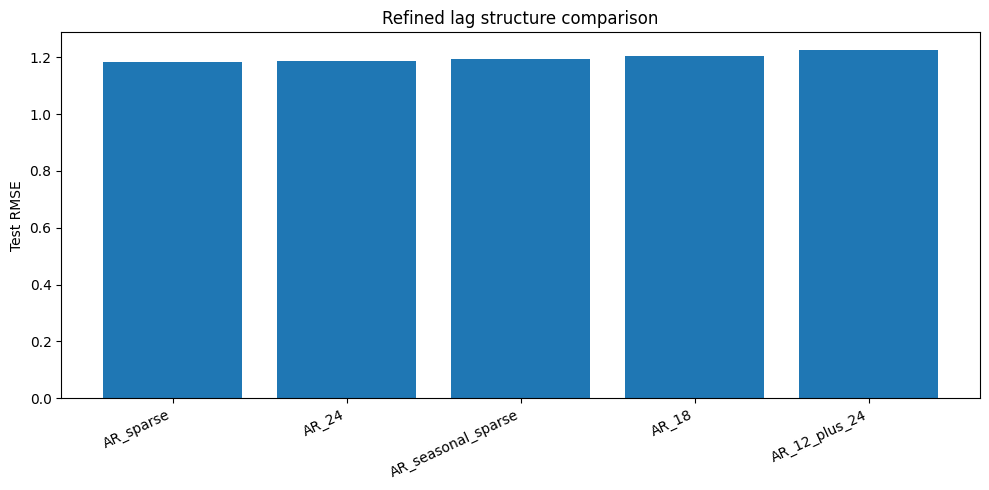

In [10]:
plot_df = ar_lag_results_df.sort_values("test_rmse").reset_index(drop=True)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["lag_structure"], plot_df["test_rmse"])
plt.xticks(rotation=25, ha="right")
plt.ylabel("Test RMSE")
plt.title("Refined lag structure comparison")
plt.tight_layout()
save_current_plot("04_temporal_feature_tuning_ar_lag_test_rmse_by_structure.png")
plt.show()

### **Plot: MAE comparison**

Saved figure: experiment_notebooks/Experiment_Images_For_Case_Analysis/04_temporal_feature_tuning_ar_lag_test_mae_by_structure.png


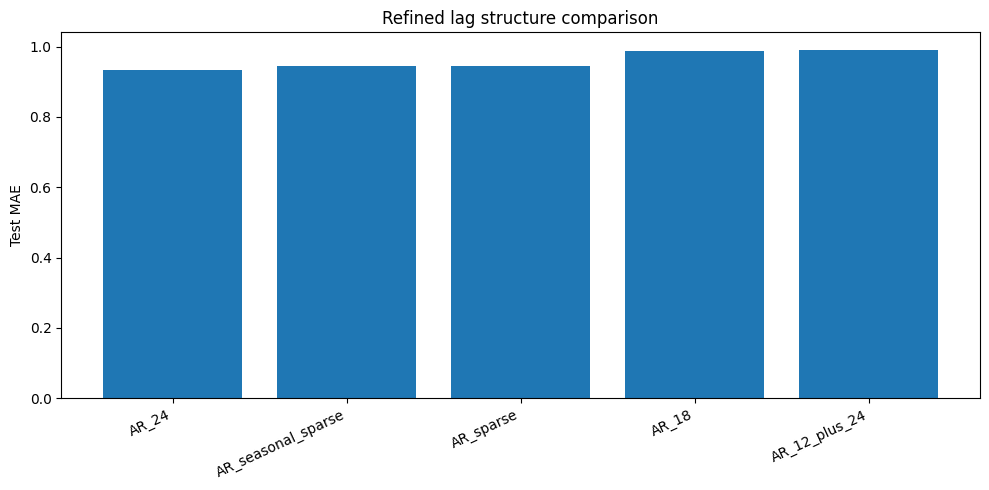

In [11]:
plot_df = ar_lag_results_df.sort_values("test_mae").reset_index(drop=True)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["lag_structure"], plot_df["test_mae"])
plt.xticks(rotation=25, ha="right")
plt.ylabel("Test MAE")
plt.title("Refined lag structure comparison")
plt.tight_layout()
save_current_plot("04_temporal_feature_tuning_ar_lag_test_mae_by_structure.png")
plt.show()

### **Full test tables**

These detailed tables show all candidate models inside each lag setting. They are useful for checking whether the lag choice or a specific model family is driving the result.

In [12]:
SHOW_FULL_TEST_TABLES = True

if SHOW_FULL_TEST_TABLES:
    for label, rr in ar_lag_run_objects.items():
        print(f"/n===== {label} : FULL TEST TABLE =====")
        display(rr.overall_test.sort_values(["RMSE", "MAE"]).reset_index(drop=True))

        choice_table = getattr(rr, "month_choice_table", None)
        if choice_table is not None:
            print(f"/n===== {label} : CHOICE TABLE =====")
            display(choice_table.reset_index())
else:
    print("Set SHOW_FULL_TEST_TABLES = True to inspect all test tables.")


===== AR_18 : FULL TEST TABLE =====


,Model,RMSE,MAE,Bias,Acc@0.25,Acc@0.35,Acc@0.50
0,PatchTST,1.154943,0.926883,-0.282317,0.136842,0.231579,0.357895
1,NHiTS,1.170945,0.943263,-0.280367,0.136842,0.221053,0.347368
2,Huber,1.184812,0.970208,-0.319308,0.105263,0.157895,0.305263
3,iTransformer,1.188387,0.951256,-0.319261,0.168421,0.252632,0.326316
4,Ridge,1.203647,0.986608,-0.281179,0.105263,0.157895,0.284211
5,LSTM,1.211446,0.985577,-0.375982,0.126316,0.178947,0.315789
6,XGBoost,1.219518,0.972848,-0.221717,0.157895,0.210526,0.305263
7,Baseline,1.337108,1.001100,-0.016177,0.210526,0.305263,0.410526



===== AR_24 : FULL TEST TABLE =====


,Model,RMSE,MAE,Bias,Acc@0.25,Acc@0.35,Acc@0.50
0,PatchTST,1.169178,0.949942,-0.324431,0.136842,0.221053,0.315789
1,iTransformer,1.186149,0.932547,-0.112656,0.189474,0.263158,0.357895
2,NHiTS,1.203926,0.965194,-0.285928,0.147368,0.221053,0.305263
3,LSTM,1.207425,0.976118,-0.366154,0.157895,0.178947,0.305263
4,Ridge,1.220340,0.995976,-0.296922,0.084211,0.168421,0.263158
5,XGBoost,1.227830,0.979179,-0.211919,0.168421,0.231579,0.347368
6,Huber,1.238328,0.984819,-0.373128,0.168421,0.231579,0.305263
7,Baseline,1.337108,1.001100,-0.016177,0.210526,0.305263,0.410526



===== AR_12_plus_24 : FULL TEST TABLE =====


,Model,RMSE,MAE,Bias,Acc@0.25,Acc@0.35,Acc@0.50
0,iTransformer,1.164725,0.920309,-0.312077,0.178947,0.263158,0.368421
1,PatchTST,1.177713,0.932456,-0.260849,0.189474,0.273684,0.347368
2,NHiTS,1.216695,0.984585,-0.389227,0.168421,0.200000,0.284211
3,Huber,1.226067,0.966489,-0.448485,0.157895,0.210526,0.294737
4,Ridge,1.226665,0.990954,-0.405588,0.094737,0.178947,0.273684
5,LSTM,1.230133,1.001961,-0.427812,0.147368,0.178947,0.273684
6,Baseline,1.337108,1.001100,-0.016177,0.210526,0.305263,0.410526
7,XGBoost,1.338116,1.088700,-0.419334,0.136842,0.168421,0.315789



===== AR_seasonal_sparse : FULL TEST TABLE =====


,Model,RMSE,MAE,Bias,Acc@0.25,Acc@0.35,Acc@0.50
0,iTransformer,1.158883,0.890054,-0.175977,0.231579,0.315789,0.410526
1,PatchTST,1.193909,0.944290,-0.334077,0.189474,0.231579,0.294737
2,LSTM,1.214946,0.996226,-0.398572,0.126316,0.178947,0.273684
3,NHiTS,1.222690,0.988317,-0.382582,0.200000,0.231579,0.305263
4,Ridge,1.235829,1.007903,-0.432893,0.115789,0.157895,0.263158
5,Huber,1.246576,1.012825,-0.513280,0.115789,0.178947,0.263158
6,XGBoost,1.335038,1.087672,-0.577134,0.126316,0.178947,0.252632
7,Baseline,1.337108,1.001100,-0.016177,0.210526,0.305263,0.410526



===== AR_sparse : FULL TEST TABLE =====


,Model,RMSE,MAE,Bias,Acc@0.25,Acc@0.35,Acc@0.50
0,iTransformer,1.156324,0.918254,-0.251868,0.168421,0.305263,0.357895
1,PatchTST,1.183638,0.944634,-0.323589,0.157895,0.242105,0.315789
2,NHiTS,1.184295,0.953493,-0.331132,0.200000,0.273684,0.273684
3,LSTM,1.220937,0.989308,-0.390648,0.157895,0.210526,0.252632
4,Ridge,1.237282,1.010480,-0.434165,0.115789,0.157895,0.263158
5,Huber,1.247404,1.014735,-0.514468,0.126316,0.189474,0.263158
6,Baseline,1.337108,1.001100,-0.016177,0.210526,0.305263,0.410526
7,XGBoost,1.358521,1.102282,-0.588097,0.147368,0.210526,0.273684


### **Save results to CSV**

In [13]:
out_dir = PROJECT_ROOT / "notebooks_outputs"
out_dir.mkdir(parents=True, exist_ok=True)

results_path = out_dir / "04_temporal_feature_tuning_ar_lag_results.csv"
ar_lag_results_df.to_csv(results_path, index=False)

print("Saved:", project_relative(results_path))

Saved: notebooks_outputs/04_temporal_feature_tuning_ar_lag_results.csv


---

# **Part 4: ENSO Lag Tuning**

The AR lag sweep narrows the autoregressive memory design. This section keeps the selected AR setup fixed and tests which ENSO lag representation is most useful.

### **Carry forward selected AR lags into ENSO tuning**

The ENSO sweep uses the best AR lag structure from Part 3. This keeps the second half of the notebook connected to the first half instead of redefining a separate setup.

In [14]:
selected_ar_lag_label = str(best_row["lag_structure"])
SELECTED_AR_LAGS = tuple(LAG_STRUCTURES[selected_ar_lag_label])
AR_LAGS_12_PLUS_24 = SELECTED_AR_LAGS

BASE_CFG.update({"ar_lags": SELECTED_AR_LAGS})

ENSO_LAG_OPTIONS = {
    "enso_0": (0,),
    "enso_0_1_3": (0, 1, 3),
    "enso_0_1_3_6": (0, 1, 3, 6),
    "enso_0_1_3_6_12": (0, 1, 3, 6, 12),
    "enso_0_1_2_3_6_9_12": (0, 1, 2, 3, 6, 9, 12),
    "enso_3_6_9_12": (3, 6, 9, 12),
}

print("Selected AR lag structure:", selected_ar_lag_label)
print("Selected AR lags:", SELECTED_AR_LAGS)
print("ENSO lag options:", ENSO_LAG_OPTIONS)
portable_config(BASE_CFG)

Selected AR lag structure: AR_sparse
Selected AR lags: (1, 2, 3, 6, 12, 18, 24)
ENSO lag options: {'enso_0': (0,), 'enso_0_1_3': (0, 1, 3), 'enso_0_1_3_6': (0, 1, 3, 6), 'enso_0_1_3_6_12': (0, 1, 3, 6, 12), 'enso_0_1_2_3_6_9_12': (0, 1, 2, 3, 6, 9, 12), 'enso_3_6_9_12': (3, 6, 9, 12)}


{'tavg_file': 'nclimgrid_tavg.nc',
 'sst_dir': 'sst_cache',
 'enso_csv': 'nina34.anom.csv',
 'random_seed': 42,
 'use_sst': False,
 'use_teleconnections': False,
 'use_qmap': False,
 'use_month_alpha_choice': False,
 'month_group_size': 12,
 'use_ridge': True,
 'use_huber': True,
 'use_xgb': True,
 'use_lstm': True,
 'use_patchtst': True,
 'use_itransformer': True,
 'use_nhits': True,
 'H': 1,
 'use_recency_weights': True,
 'half_life_months': 48,
 'residual_deseasonalize': False,
 'plot_test': False,
 'verbose': True,
 'ar_lags': (1, 2, 3, 6, 12, 18, 24)}

### **Run helpers**

These helpers run one ENSO-lag configuration and collect the selected global model metrics. They keep the sweep code compact and make each ENSO option comparable.

In [15]:
def summarize_enso_lag_run(rr, enso_name, enso_lags):
    base = _summarize_run(rr, enso_name, label_field="enso_option")
    return {
        "enso_option": enso_name,
        "enso_lags": tuple(enso_lags),
        "feature_setup": "AR_plus_enso",
        "ar_lags": AR_LAGS_12_PLUS_24,
        "recency_half_life_months": BASE_CFG["half_life_months"],
        "month_group_size": BASE_CFG["month_group_size"],
        "final_model": base["final_model"],
        "chosen_models": base["chosen_models"],
        "best_val_model": base["global_val_best_model"],
        "val_rmse": base["global_val_rmse"],
        "val_mae": base["global_val_mae"],
        "test_rmse": base["test_rmse"],
        "test_mae": base["test_mae"],
        "test_bias": base["test_bias"],
        "baseline_rmse": base.get("baseline_test_rmse", np.nan),
        "baseline_mae": base.get("baseline_test_mae", np.nan),
        "dRMSE_vs_baseline": base.get("dRMSE_vs_baseline", np.nan),
        "dMAE_vs_baseline": base.get("dMAE_vs_baseline", np.nan),
        "run_id": base["run_id"],
    }


def run_enso_lag_experiment(enso_name: str, enso_lags):
    cfg = ForecasterConfig(**{
        **BASE_CFG,
        "enso_lags": tuple(enso_lags),
    })

    rr = run_backtest(cfg)

    return {
        "run_result": rr,
        "summary": summarize_enso_lag_run(rr, enso_name, enso_lags),
        "overall_val": rr.overall_val.copy(),
        "overall_test": rr.overall_test.copy(),
        "month_choice_table": getattr(rr, "month_choice_table", None),
    }

---

# **Part 5: Run the ENSO lag sweep**

This loop reruns the selected forecast setup for each ENSO lag set. It tests whether current ENSO alone is enough or whether delayed ENSO history improves forecasts.


In [16]:
results_by_enso = {}
summary_rows = []
overall_test_rows = []
month_choice_rows = []

for enso_name, enso_lags in ENSO_LAG_OPTIONS.items():
    print("=" * 100)
    print(f"Running ENSO option: {enso_name}")
    print("enso_lags:", enso_lags)
    rr = run_enso_lag_experiment(enso_name, enso_lags)
    results_by_enso[enso_name] = rr
    summary_rows.append(rr["summary"])

    overall_test = rr["overall_test"].copy()
    overall_test["enso_option"] = enso_name
    overall_test["enso_lags"] = str(tuple(enso_lags))
    overall_test_rows.append(overall_test)

    choice_table = rr["month_choice_table"]
    if choice_table is not None:
        choice_table = choice_table.copy()
        choice_table["enso_option"] = enso_name
        choice_table["enso_lags"] = str(tuple(enso_lags))
        month_choice_rows.append(choice_table)

print("Finished ENSO lag sweep.")

Running ENSO option: enso_0
enso_lags: (0,)
[BOOT] Starting backtest

===== SPLIT INFO (TARGET MONTHS) =====
Train: 1950-01-01 -> 2009-12-01 (n=720)
Val  : 2010-01-01   -> 2017-12-01   (n=96)
Test : 2018-01-01  -> 2025-11-01  (n=95)
Running ENSO option: enso_0_1_3
enso_lags: (0, 1, 3)
[BOOT] Starting backtest

===== SPLIT INFO (TARGET MONTHS) =====
Train: 1950-01-01 -> 2009-12-01 (n=720)
Val  : 2010-01-01   -> 2017-12-01   (n=96)
Test : 2018-01-01  -> 2025-11-01  (n=95)
Running ENSO option: enso_0_1_3_6
enso_lags: (0, 1, 3, 6)
[BOOT] Starting backtest

===== SPLIT INFO (TARGET MONTHS) =====
Train: 1950-01-01 -> 2009-12-01 (n=720)
Val  : 2010-01-01   -> 2017-12-01   (n=96)
Test : 2018-01-01  -> 2025-11-01  (n=95)
Running ENSO option: enso_0_1_3_6_12
enso_lags: (0, 1, 3, 6, 12)
[BOOT] Starting backtest

===== SPLIT INFO (TARGET MONTHS) =====
Train: 1950-01-01 -> 2009-12-01 (n=720)
Val  : 2010-01-01   -> 2017-12-01   (n=96)
Test : 2018-01-01  -> 2025-11-01  (n=95)
Running ENSO option: ens

---

# **Part 6: ENSO Lag-Sweep Results**

This section compares ENSO lag options overall and inspects which model is selected under the fixed global-selection setup.


### **Overall Test Results by ENSO Lag Option****


In [17]:
enso_summary_df = pd.DataFrame(summary_rows).sort_values(["test_rmse", "test_mae"]).reset_index(drop=True)
enso_summary_df

,enso_option,enso_lags,feature_setup,ar_lags,recency_half_life_months,month_group_size,final_model,chosen_models,best_val_model,val_rmse,val_mae,test_rmse,test_mae,test_bias,baseline_rmse,baseline_mae,dRMSE_vs_baseline,dMAE_vs_baseline,run_id
0,enso_0,"(0,)",AR_plus_enso,"(1, 2, 3, 6, 12, 18, 24)",48,12,PatchTST,,PatchTST,1.054739,0.824241,1.163232,0.924888,-0.295135,1.337108,1.0011,-0.173876,-0.076212,runs/official_backtest_20260820_234000_utc
1,enso_0_1_3_6,"(0, 1, 3, 6)",AR_plus_enso,"(1, 2, 3, 6, 12, 18, 24)",48,12,PatchTST,,PatchTST,1.054303,0.833640,1.172142,0.929576,-0.307128,1.337108,1.0011,-0.164967,-0.071524,runs/official_backtest_20260820_234309_utc
2,enso_0_1_3_6_12,"(0, 1, 3, 6, 12)",AR_plus_enso,"(1, 2, 3, 6, 12, 18, 24)",48,12,PatchTST,,PatchTST,1.059114,0.838415,1.183638,0.944634,-0.323589,1.337108,1.0011,-0.153470,-0.056466,runs/official_backtest_20260820_234508_utc
3,enso_3_6_9_12,"(3, 6, 9, 12)",AR_plus_enso,"(1, 2, 3, 6, 12, 18, 24)",48,12,PatchTST,,PatchTST,1.059158,0.838353,1.183712,0.944694,-0.323170,1.337108,1.0011,-0.153396,-0.056406,runs/official_backtest_20260820_234839_utc
4,enso_0_1_3,"(0, 1, 3)",AR_plus_enso,"(1, 2, 3, 6, 12, 18, 24)",48,12,PatchTST,,PatchTST,1.065804,0.843479,1.185735,0.946236,-0.336812,1.337108,1.0011,-0.151374,-0.054864,runs/official_backtest_20260820_234140_utc
5,enso_0_1_2_3_6_9_12,"(0, 1, 2, 3, 6, 9, 12)",AR_plus_enso,"(1, 2, 3, 6, 12, 18, 24)",48,12,NHiTS,,NHiTS,1.053490,0.808928,1.230030,0.975022,-0.326683,1.337108,1.0011,-0.107078,-0.026078,runs/official_backtest_20260820_234652_utc


### **ENSO Lag-Sweep Summary**

In [18]:
overall_test_long_df = pd.concat(overall_test_rows, ignore_index=True)
overall_test_long_df.sort_values(["enso_option", "RMSE", "MAE"]).reset_index(drop=True)

,Model,RMSE,MAE,Bias,Acc@0.25,Acc@0.35,Acc@0.50,enso_option,enso_lags
0,PatchTST,1.163232,0.924888,-0.295135,0.178947,0.242105,0.347368,enso_0,"(0,)"
1,iTransformer,1.207362,0.978816,-0.383053,0.126316,0.200000,0.273684,enso_0,"(0,)"
2,LSTM,1.215480,0.988222,-0.390913,0.168421,0.210526,0.252632,enso_0,"(0,)"
3,NHiTS,1.218945,0.980494,-0.328321,0.157895,0.221053,0.305263,enso_0,"(0,)"
4,Ridge,1.237282,1.010480,-0.434166,0.115789,0.157895,0.263158,enso_0,"(0,)"
5,Huber,1.243899,1.012891,-0.502665,0.136842,0.189474,0.252632,enso_0,"(0,)"
6,XGBoost,1.322132,1.041734,-0.578331,0.147368,0.178947,0.315789,enso_0,"(0,)"
7,Baseline,1.337108,1.001100,-0.016177,0.210526,0.305263,0.410526,enso_0,"(0,)"
8,iTransformer,1.151229,0.888623,-0.136933,0.252632,0.305263,0.410526,enso_0_1_2_3_6_9_12,"(0, 1, 2, 3, 6, 9, 12)"
9,PatchTST,1.173395,0.934157,-0.296655,0.147368,0.252632,0.336842,enso_0_1_2_3_6_9_12,"(0, 1, 2, 3, 6, 9, 12)"


### **Month-choice membership**

This table shows which model won inside each seasonal month group for each ENSO lag option. It helps explain whether a lag choice changes the ensemble composition.

In [19]:
if month_choice_rows:
    month_choice_long_df = pd.concat(month_choice_rows, ignore_index=True)
else:
    month_choice_long_df = pd.DataFrame()

month_choice_long_df

""


### **Plot: RMSE comparison**

The RMSE plot makes it easier to see whether one ENSO lag set is clearly better or whether the leading options are effectively tied.

  plt.legend()


Saved figure: experiment_notebooks/Experiment_Images_For_Case_Analysis/04_temporal_feature_tuning_enso_lag_test_rmse_by_set.png


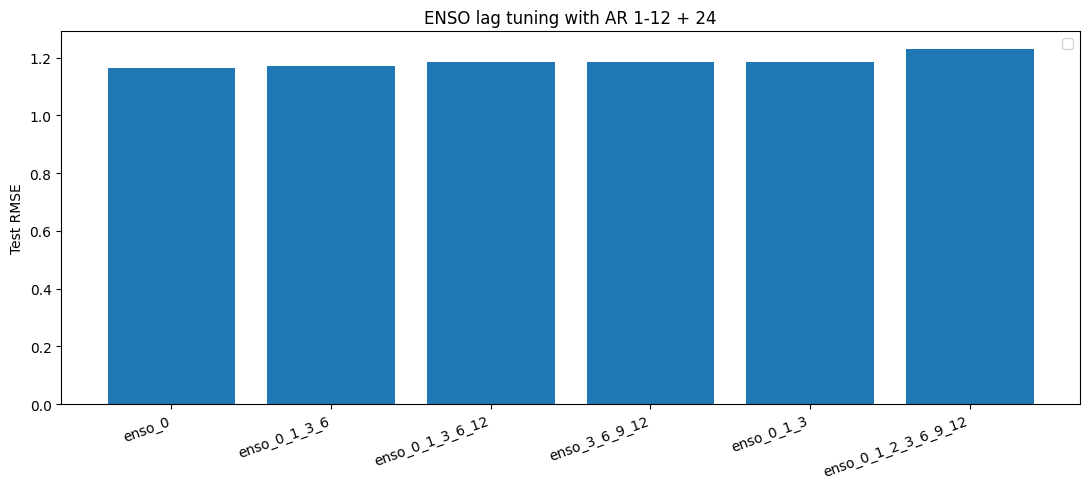

In [20]:
plot_df = enso_summary_df.sort_values("test_rmse").reset_index(drop=True)

plt.figure(figsize=(11, 5))
plt.bar(plot_df["enso_option"], plot_df["test_rmse"])
plt.ylabel("Test RMSE")
plt.title("ENSO lag tuning with AR 1-12 + 24")
plt.xticks(rotation=20, ha="right")
plt.legend()
plt.tight_layout()
save_current_plot("04_temporal_feature_tuning_enso_lag_test_rmse_by_set.png")
plt.show()

### **Save outputs**

In [21]:
out_dir = PROJECT_ROOT / "notebooks_outputs"
out_dir.mkdir(parents=True, exist_ok=True)

summary_path = out_dir / "04_temporal_feature_tuning_enso_lag_summary.csv"
overall_test_path = out_dir / "04_temporal_feature_tuning_enso_lag_overall_test_long.csv"
month_choice_path = out_dir / "04_temporal_feature_tuning_enso_lag_month_choice_long.csv"

enso_summary_df.to_csv(summary_path, index=False)
overall_test_long_df.to_csv(overall_test_path, index=False)
month_choice_long_df.to_csv(month_choice_path, index=False)

print("Saved:", project_relative(summary_path))
print("Saved:", project_relative(overall_test_path))
print("Saved:", project_relative(month_choice_path))

Saved: notebooks_outputs/04_temporal_feature_tuning_enso_lag_summary.csv
Saved: notebooks_outputs/04_temporal_feature_tuning_enso_lag_overall_test_long.csv
Saved: notebooks_outputs/04_temporal_feature_tuning_enso_lag_month_choice_long.csv


---

# **Part 7: Conclusion**

### **Overall Takeaways:**

- Notebook 04 tests temporal feature design after fixing the AR + ENSO feature scope, 48-month recency weighting, and global model-selection setup from Notebook 03.
- The AR lag sweep favors the sparse extended-memory design. AR_sparse gives the best test RMSE in the sweep, with PatchTST selected globally and a test RMSE near 1.184. The simpler AR_12_plus_24 setup is noticeably weaker.
- Carrying the sparse AR design into the ENSO sweep shows that current ENSO alone is the strongest held-out option. enso_0 gives the lowest test RMSE near 1.163, while longer ENSO histories do not improve generalization.
- Validation and test results are close for the leading ENSO options, but the longest lag set enso_0_1_2_3_6_9_12 looks less stable: it has strong validation MAE but much worse test RMSE.
- The temporal-feature results support a compact global setup: sparse extended AR lags, current ENSO anomaly, 48-month recency weighting, and no seasonal month-choice.

---